In [24]:
import time as t
import matplotlib.pyplot as plt

In [1]:
def create(x,y):
    return [[0 for j in range(y)] for i in range(x)]

def disp(X):
    for i in X:
        for j in i:
            print(j,end=" ")
        print()
    print()

### Brute Force using For Loop

#### N^3

In [2]:
def matrix_mult(A,B):
    m1 = len(A)
    n1 = len(A[0])
    m2 = len(B)
    n2 = len(B[0])
    if n1!=m2:
        raise IndexError
    Ans = create(m1,n2)
    for i in range(m1):
        for j in range(n2):
            for k in range(n1):
                Ans[i][j]+=A[i][k]*B[k][j]
    return Ans
    

A = [[1,0],[0,1]]
B = [[1,2],[3,4]]
disp(A)
disp(B)
disp(matrix_mult(A,B))

1 0 
0 1 

1 2 
3 4 

1 2 
3 4 



### Divide and Conqour I guess

#### N^3

In [3]:
def create(x,y):
    return [[0 for j in range(y)] for i in range(x)]

In [19]:
def Divide(X):
    n = len(X)//2
    X11 = create(n,n)
    X12 = create(n,n)
    X21 = create(n,n)
    X22 = create(n,n)
    disp(X)
    for i in range(n):
        for j in range(n):
            X11[i][j] = X[i][j]
            X12[i][j] = X[i][j+n]
            X21[i][j] = X[i+n][j]
            X22[i][j] = X[i+n][j+n]
    return X11,X12,X21,X22

def Combine(X11,X12,X21,X22):
    n = len(X11)
    Ans = create(n*2,n*2)
    for i in range(n):
        for j in range(n):

            Ans[i][j]=X11[i][j]
            Ans[i][j+n] = X12[i][j]
            Ans[i+n][j] = X21[i][j]
            Ans[i+n][j+n] = X22[i][j]
    return Ans

def matrix_mult_dc(A,B,C,n):
    if n==1:
        C[0][0] += A[0][0]*B[0][0]
        return C
    A11,A12,A21,A22 = Divide(A)
    B11,B12,B21,B22 = Divide(B)
    C11,C12,C21,C22 = Divide(C)
    C11 = matrix_mult_dc(A11,B11,C11,n/2)
    C12 = matrix_mult_dc(A11,B12,C12,n/2)
    C21 = matrix_mult_dc(A21,B11,C21,n/2)
    C22 = matrix_mult_dc(A21,B12,C22,n/2)
    C11 = matrix_mult_dc(A12,B21,C11,n/2)
    C12 = matrix_mult_dc(A12,B22,C12,n/2)
    C21 = matrix_mult_dc(A22,B21,C21,n/2)
    C22 = matrix_mult_dc(A22,B22,C22,n/2)
    return Combine(C11,C12,C21,C22)

A = [[1,0],[0,1]]
B = [[1,2],[3,4]]
C = create(len(A),len(B[0]))


'''
A11,A12,A21,A22 = Divide(A)
disp(A11)
disp(A12)
disp(A21)
disp(A22)

disp(Combine(A11,A12,A21,A22))
'''

disp(matrix_mult_dc(A,B,C,2))

1 0 
0 1 

1 2 
3 4 

0 0 
0 0 

1 2 
3 4 



### Strassen’s algorithm for matrix multiplication

#### N^(log7)

In [11]:
def Divide(X):

    n = len(X)//2

    X11 = create(n,n)
    X12 = create(n,n)
    X21 = create(n,n)
    X22 = create(n,n)
    disp(X)

    for i in range(n):
        for j in range(n):
            X11[i][j] = X[i][j]
            X12[i][j] = X[i][j+n]
            X21[i][j] = X[i+n][j]
            X22[i][j] = X[i+n][j+n]

    return X11,X12,X21,X22

def Combine(X11,X12,X21,X22):

    n = len(X11)
    Ans = create(n*2,n*2)

    for i in range(n):
        for j in range(n):
            Ans[i][j]=X11[i][j]
            Ans[i][j+n] = X12[i][j]
            Ans[i+n][j] = X21[i][j]
            Ans[i+n][j+n] = X22[i][j]
            
    return Ans

def addMatrix(A,B,sign=1):

    if len(A)!=len(B) and len(A[0])!=len(B[0]):
        raise IndexError
    
    Ans = create(len(A),len(A[0]))

    for i in range(len(A)):
        for j in range(len(A[0])):
            Ans[i][j] = A[i][j] + sign*B[i][j]
            
    return Ans

def matrix_mult_s(A,B,C,n):

    if n==1:
        C[0][0] += A[0][0]*B[0][0]
        return C
    
    A11,A12,A21,A22 = Divide(A)
    B11,B12,B21,B22 = Divide(B)
    C11,C12,C21,C22 = Divide(C)

    S1 = addMatrix(A11,A22)
    S2 = addMatrix(B11,B22)
    S3 = addMatrix(A21,A22)
    S4 = addMatrix(B12,B22,-1)
    S5 = addMatrix(B21,B11,-1)
    S6 = addMatrix(A11,A12)
    S7 = addMatrix(A21,A11,-1)
    S8 = addMatrix(B11,B12)
    S9 = addMatrix(A12,A22,-1)
    S10 = addMatrix(B21,B22)

    P1 = matrix_mult_s(S1,S2,create(len(A11),len(A11[0])),n//2)
    P2 = matrix_mult_s(S3,B11,create(len(A11),len(A11[0])),n//2)
    P3 = matrix_mult_s(A11,S4,create(len(A11),len(A11[0])),n//2)
    P4 = matrix_mult_s(A22,S5,create(len(A11),len(A11[0])),n//2)
    P5 = matrix_mult_s(S6,B22,create(len(A11),len(A11[0])),n//2)
    P6 = matrix_mult_s(S7,S8,create(len(A11),len(A11[0])),n//2)
    P7 = matrix_mult_s(S9,S10,create(len(A11),len(A11[0])),n//2)

    # C11 = addMatrix(C11,addMatrix)
    C11 = addMatrix(addMatrix(addMatrix(P1, P4), P5, -1), P7)
    C12 = addMatrix(P3, P5)
    C21 = addMatrix(P2, P4)
    C22 = addMatrix(addMatrix(addMatrix(P1, P2,-1), P3), P6)

    return Combine(C11,C12,C21,C22)

A = [[1,2],[3,4]]
B = [[2,1],[3,4]]

#disp(addMatrix(A,B,-1))

C = create(len(A),len(B[0]))


'''
A11,A12,A21,A22 = Divide(A)
disp(A11)
disp(A12)
disp(A21)
disp(A22)

disp(Combine(A11,A12,A21,A22))
'''

disp(matrix_mult_s(A,B,C,2))

1 2 
3 4 

2 1 
3 4 

0 0 
0 0 

8 9 
18 19 



1 2 
3 4 

5 6 
7 8 

0 0 
0 0 

1 2 
3 4 

5 6 
7 8 

0 0 
0 0 

1 2 3 4 
5 6 7 8 
9 10 11 12 
13 14 15 16 

16 15 14 13 
12 11 10 9 
8 7 6 5 
4 3 2 1 

0 0 0 0 
0 0 0 0 
0 0 0 0 
0 0 0 0 

12 14 
20 22 

22 20 
14 12 

0 0 
0 0 

20 22 
28 30 

16 15 
12 11 

0 0 
0 0 

1 2 
5 6 

8 8 
8 8 

0 0 
0 0 

11 12 
15 16 

-8 -8 
-8 -8 

0 0 
0 0 

4 6 
12 14 

6 5 
2 1 

0 0 
0 0 

8 8 
8 8 

30 28 
22 20 

0 0 
0 0 

-8 -8 
-8 -8 

14 12 
6 4 

0 0 
0 0 

1 2 3 4 
5 6 7 8 
9 10 11 12 
13 14 15 16 

16 15 14 13 
12 11 10 9 
8 7 6 5 
4 3 2 1 

0 0 0 0 
0 0 0 0 
0 0 0 0 
0 0 0 0 

1 2 
5 6 

16 15 
12 11 

0 0 
0 0 

1 2 
5 6 

14 13 
10 9 

0 0 
0 0 

9 10 
13 14 

16 15 
12 11 

0 0 
0 0 

9 10 
13 14 

14 13 
10 9 

0 0 
0 0 

3 4 
7 8 

8 7 
4 3 

40 37 
152 141 

3 4 
7 8 

6 5 
2 1 

34 31 
130 119 

11 12 
15 16 

8 7 
4 3 

264 245 
376 349 

11 12 
15 16 

6 5 
2 1 

226 207 
322 295 

1 0 0 0 
0 2 0 0 
0 0 3 0 
0 0 0 4 

4 0 0 0 
0 3 0 0 
0 0 2 0 
0 0 0 1 

0 0 0 0 
0 0 0 0 
0 0 0

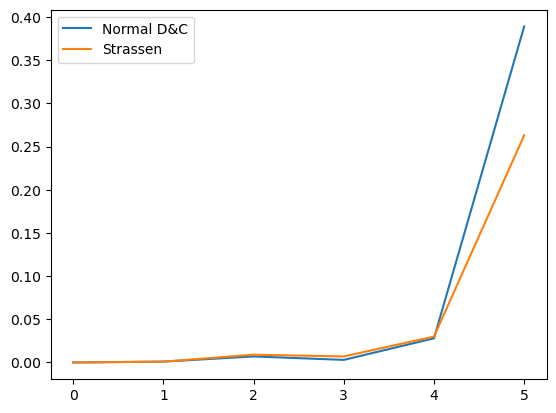

In [31]:
def check(X,Y):
    for i in range(len(X)):
        for j in range(len(X[i])):
            if X[i][j]!=Y[i][j]:
                return False
    return True

test = [{
    "A": [[5]],
    "B": [[3]],
    "C": [[15]]
},
{
    "A": [
        [1, 2],
        [3, 4]
    ],
    "B": [
        [5, 6],
        [7, 8]
    ],
    "C": [
        [19, 22],
        [43, 50]
    ]
},{
    "A": [
        [1, 2, 3, 4],
        [5, 6, 7, 8],
        [9, 10, 11, 12],
        [13, 14, 15, 16]
    ],
    "B": [
        [16, 15, 14, 13],
        [12, 11, 10, 9],
        [8, 7, 6, 5],
        [4, 3, 2, 1]
    ],
    "C": [
        [80, 70, 60, 50],
        [240, 214, 188, 162],
        [400, 358, 316, 274],
        [560, 502, 444, 386]
    ]
},{
    "A": [
        [1, 0, 0, 0],
        [0, 2, 0, 0],
        [0, 0, 3, 0],
        [0, 0, 0, 4]
    ],
    "B": [
        [4, 0, 0, 0],
        [0, 3, 0, 0],
        [0, 0, 2, 0],
        [0, 0, 0, 1]
    ],
    "C": [
        [4, 0, 0, 0],
        [0, 6, 0, 0],
        [0, 0, 6, 0],
        [0, 0, 0, 4]
    ]
},{
    "A": [
        [1,1,1,1,1,1,1,1],
        [2,2,2,2,2,2,2,2],
        [3,3,3,3,3,3,3,3],
        [4,4,4,4,4,4,4,4],
        [5,5,5,5,5,5,5,5],
        [6,6,6,6,6,6,6,6],
        [7,7,7,7,7,7,7,7],
        [8,8,8,8,8,8,8,8]
    ],
    "B": [
        [1,2,3,4,5,6,7,8],
        [1,2,3,4,5,6,7,8],
        [1,2,3,4,5,6,7,8],
        [1,2,3,4,5,6,7,8],
        [1,2,3,4,5,6,7,8],
        [1,2,3,4,5,6,7,8],
        [1,2,3,4,5,6,7,8],
        [1,2,3,4,5,6,7,8]
    ],
    "C": [
        [8,16,24,32,40,48,56,64],
        [16,32,48,64,80,96,112,128],
        [24,48,72,96,120,144,168,192],
        [32,64,96,128,160,192,224,256],
        [40,80,120,160,200,240,280,320],
        [48,96,144,192,240,288,336,384],
        [56,112,168,224,280,336,392,448],
        [64,128,192,256,320,384,448,512]
    ]
}]

test.append({
    "A": [
        [1]*16,
        [2]*16,
        [3]*16,
        [4]*16,
        [5]*16,
        [6]*16,
        [7]*16,
        [8]*16,
        [9]*16,
        [10]*16,
        [11]*16,
        [12]*16,
        [13]*16,
        [14]*16,
        [15]*16,
        [16]*16
    ],
    "B": [
        [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16],
        [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16],
        [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16],
        [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16],
        [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16],
        [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16],
        [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16],
        [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16],
        [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16],
        [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16],
        [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16],
        [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16],
        [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16],
        [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16],
        [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16],
        [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16]
    ],
    "C": [
        [16,32,48,64,80,96,112,128,144,160,176,192,208,224,240,256],
        [32,64,96,128,160,192,224,256,288,320,352,384,416,448,480,512],
        [48,96,144,192,240,288,336,384,432,480,528,576,624,672,720,768],
        [64,128,192,256,320,384,448,512,576,640,704,768,832,896,960,1024],
        [80,160,240,320,400,480,560,640,720,800,880,960,1040,1120,1200,1280],
        [96,192,288,384,480,576,672,768,864,960,1056,1152,1248,1344,1440,1536],
        [112,224,336,448,560,672,784,896,1008,1120,1232,1344,1456,1568,1680,1792],
        [128,256,384,512,640,768,896,1024,1152,1280,1408,1536,1664,1792,1920,2048],
        [144,288,432,576,720,864,1008,1152,1296,1440,1584,1728,1872,2016,2160,2304],
        [160,320,480,640,800,960,1120,1280,1440,1600,1760,1920,2080,2240,2400,2560],
        [176,352,528,704,880,1056,1232,1408,1584,1760,1936,2112,2288,2464,2640,2816],
        [192,384,576,768,960,1152,1344,1536,1728,1920,2112,2304,2496,2688,2880,3072],
        [208,416,624,832,1040,1248,1456,1664,1872,2080,2288,2496,2704,2912,3120,3328],
        [224,448,672,896,1120,1344,1568,1792,2016,2240,2464,2688,2912,3136,3360,3584],
        [240,480,720,960,1200,1440,1680,1920,2160,2400,2640,2880,3120,3360,3600,3840],
        [256,512,768,1024,1280,1536,1792,2048,2304,2560,2816,3072,3328,3584,3840,4096]
    ]
}
)

answer = []
s_time = []
dc_time = []
for i in range(len(test)):
    A = test[i]["A"]
    B = test[i]["B"]
    C = test[i]["C"]
    time = t.time()
    temp1 = check(matrix_mult_s(A,B,create(len(A),len(B[0])),len(A)),C)
    s_time.append(round(t.time()-time,3))
    time = t.time()
    temp2 = check(matrix_mult_dc(A,B,create(len(A),len(B[0])),len(A)),C)
    dc_time.append(round(t.time()-time,3))
    answer.append(temp1)
print(dc_time)
print(s_time)
print(answer)
plt.plot(dc_time)
plt.plot(s_time)
plt.legend(["Normal D&C","Strassen"])
plt.show()
